With the following code we want to discover possible clusters in a dataset that contains temporal series of data, in which every row corresponds to the temporal evolution of the heartbeat. The goal is to distinguish cases according to the patient's pathology.

To transport data into numpy we use a library called sktime beacause the dataset file is not in .csv format.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sktime.datasets import load_from_tsfile

K = 5
N_ITER = 10

x_train, y_train = load_from_tsfile(
    "ECG5000_TRAIN.ts",
    return_data_type = "numpy2d"
)

x_test, y_test = load_from_tsfile(
    "ECG5000_TEST.ts",
    return_data_type = "numpy2d"
)

print(f"Dataset shape x: {x_train.shape}")
print(f"Dataset shape y: {y_train.shape}")

Dataset shape x: (500, 140)
Dataset shape y: (500,)


Draw representatives.

In [8]:
rng = np.random.default_rng(seed=33)
representatives_index = rng.choice(x_train.shape[0], size=K, replace=False)
representatives = x_train[representatives_index]
print(f"Extracted indexes : {representatives_index}")
print(f"Extracted representatives : {representatives}")

Extracted indexes : [189 283 435 220 415]
Extracted representatives : [[-1.7522274e+00 -3.0484714e+00 -3.2985180e+00 -3.9577832e+00
  -4.0019439e+00 -3.6621479e+00 -2.7180751e+00 -1.8179748e+00
  -1.3349230e+00 -9.5424698e-01 -5.9292414e-01 -3.6086213e-01
  -2.8308377e-01 -3.2983300e-01 -3.3953253e-01 -3.2941492e-01
  -2.4590200e-01 -2.0983401e-01 -1.8745639e-01 -1.5043406e-01
  -2.0634927e-01 -2.1112684e-01 -1.5238707e-01 -2.1736232e-01
  -1.7597796e-01 -6.1719944e-02 -7.2572645e-02 -7.3465179e-02
  -7.3250957e-02 -1.9023572e-02 -3.8230918e-02 -5.7452311e-02
  -6.0604387e-02 -8.8237017e-02 -1.1348058e-01 -7.0568076e-02
  -8.0600437e-02 -1.6064920e-01 -1.5859298e-01 -8.5383854e-02
  -1.5033508e-01 -1.0285800e-01 -1.7931779e-01 -2.0968788e-01
  -1.1698179e-01 -1.8549543e-01 -1.2906011e-01 -6.2230578e-02
  -9.0365470e-02 -3.7406655e-02 -4.6401093e-02 -8.4115476e-02
  -1.4286312e-01 -8.7404160e-02 -9.1972141e-02 -7.4852495e-02
  -1.2349185e-01 -1.8603788e-01 -2.5145662e-01 -2.1182340e-01


Cicle to obtain the clusters.

In [9]:
def dist(diff):
    return np.sqrt(np.sum(diff**2, axis=1))

for num_iterations in range(N_ITER):
    old_representatives = representatives.copy()
    labels = np.zeros(x_train.shape[0], dtype=int)
    for i in range(x_train.shape[0]):
        labels[i] = np.argmin(dist(representatives-x_train[i]))

    for k in range(K):
        cluster_points = x_train[labels==k]
        if len(cluster_points) > 0:
            representatives[k] = np.mean(cluster_points, axis=0)
    if np.all(old_representatives == representatives):
        print(f"Convergence achieved after {num_iterations} iterations!!!")

Plotting the graphs of each cluster to display the differnce betweem them. We can see that the obtained results are not optimal due to the impossibility of the Euclidean mean to catch the temporal shifting of signals.

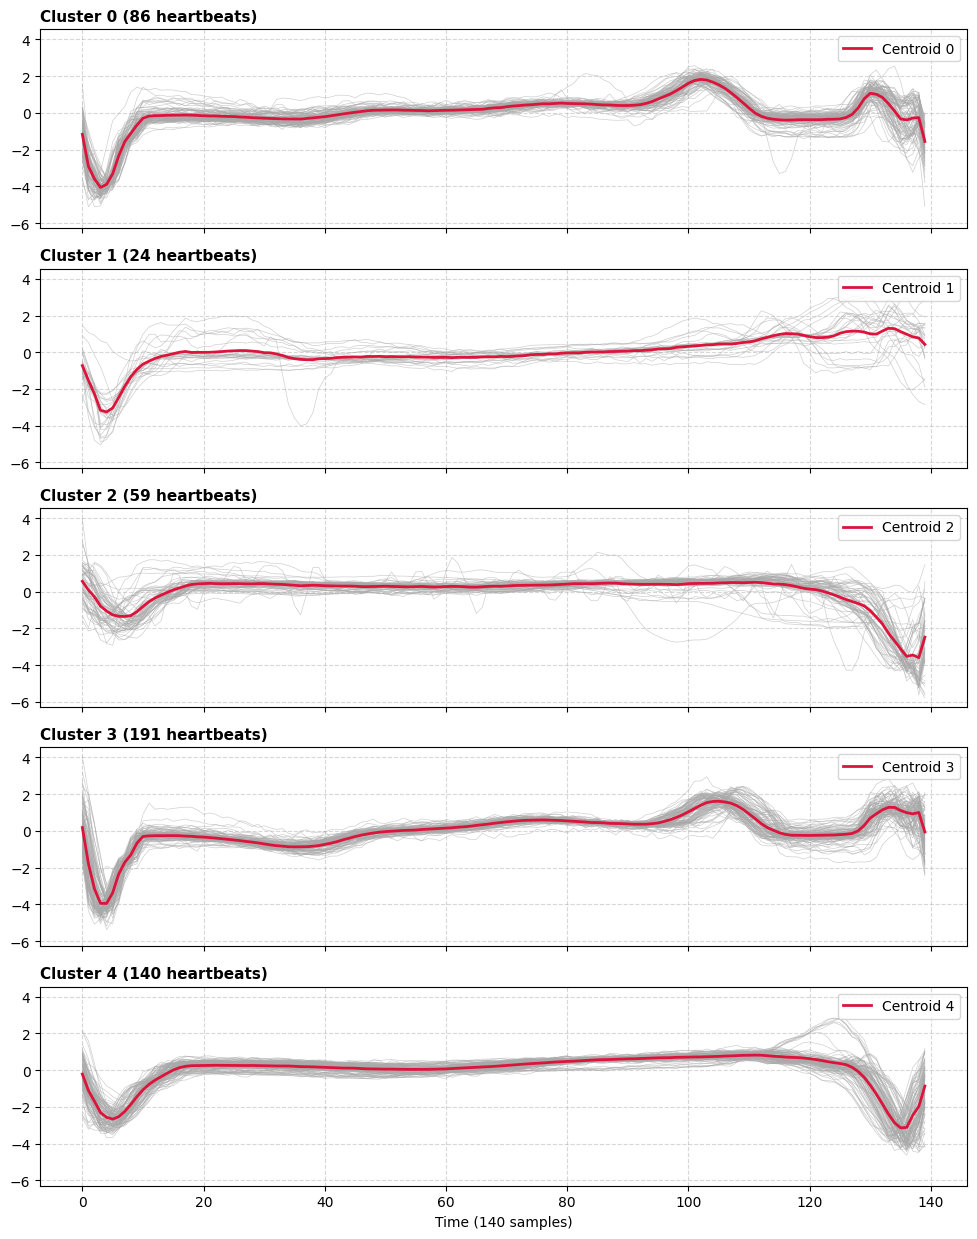

In [10]:
fig, axes = plt.subplots(K, 1, figsize=(10, 2.5 * K), sharex=True, sharey=True)
MAX_CURVES = 100
for k in range(K):
    cluster_signals = x_train[labels == k]
    ax = axes[k]
    for signal in cluster_signals[:MAX_CURVES]:
        ax.plot(signal, color='darkgray', alpha=0.55, linewidth=0.5)
    
    ax.plot(representatives[k], color='crimson', linewidth=2, label=f'Centroid {k}')
    ax.set_title(f"Cluster {k} ({len(cluster_signals)} heartbeats)", fontsize=11, fontweight='bold', loc='left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel("Time (140 samples)")
plt.tight_layout()
plt.show()

Using sklearn to analayze the results. The value returned is clipped between -1 and +1.

In [11]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil = silhouette_score(x_train, labels)
print(f"Silhouette Score globale: {sil:.3f}")

Silhouette Score globale: 0.215


In [12]:
np.savez("risultati_kmeans.npz", x_train=x_train, labels=labels, representatives=representatives)